# Credit Card Fraud Detection using Machine Learning

## Project Overview

Credit card fraud has become one of the major financial security challenges worldwide. Fraudulent transactions result in significant financial losses for both customers and banks.

The objective of this project is to build and compare multiple machine learning classification models to accurately identify fraudulent transactions. The best-performing model is selected based on evaluation metrics and later deployed as a web application using Streamlit.

## Import Required Libraries

In this section, all required Python libraries are imported for data manipulation, visualization, preprocessing, machine learning model building, evaluation, and deployment.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

### Observation

All the required libraries were successfully imported.

These libraries are used for:

- Data manipulation using Pandas and NumPy
- Data visualization using Matplotlib and Seaborn
- Data preprocessing using StandardScaler
- Handling class imbalance using SMOTE
- Building multiple machine learning models
- Evaluating model performance
- Saving the final trained model

## Load Dataset

The dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [18]:
df = pd.read_csv("credit_card_fraud.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Observation

The dataset was successfully loaded into the DataFrame.

The first five records provide an initial understanding of the available features and target variable.

## Dataset Information

Before building a machine learning model, it is important to understand the dataset structure.

In [19]:
print("Shape :", df.shape)

df.info()

df.describe().T

Shape : (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Observation

- Total number of rows and columns were identified.
- Feature data types were verified.
- Statistical summary of numerical features was obtained.
- This helps understand the distribution of the dataset before preprocessing.

## Missing Value Analysis

Machine learning models cannot effectively learn from incomplete data. Therefore, missing values are identified before preprocessing.

In [20]:
missing_values = df.isnull().sum()

print(missing_values)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Observation

No missing values were found in the dataset.

Therefore, no imputation techniques were required.

## Duplicate Record Analysis

Duplicate records can bias the model by repeating the same information multiple times.

Therefore, duplicate transactions are identified and removed.

In [21]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("Remaining Duplicates :", df.duplicated().sum())

Duplicate Records : 1081
Remaining Duplicates : 0


### Observation

Duplicate records were successfully identified and removed.

Removing duplicate records improves model generalization and prevents repeated learning of identical samples.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of data, identify class imbalance, analyze feature relationships, and gain insights before training machine learning models.

## Class Distribution

The target variable is analyzed to determine whether the dataset is balanced or imbalanced.

In [22]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_smote))

log_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

log_model.fit(X_train_smote, y_train_smote)
dt_model.fit(X_train_smote, y_train_smote)

log_prediction = log_model.predict(X_test)
dt_prediction = dt_model.predict(X_test)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_prediction),
        accuracy_score(y_test, dt_prediction)
    ],
    "Precision": [
        precision_score(y_test, log_prediction),
        precision_score(y_test, dt_prediction)
    ],
    "Recall": [
        recall_score(y_test, log_prediction),
        recall_score(y_test, dt_prediction)
    ],
    "F1 Score": [
        f1_score(y_test, log_prediction),
        f1_score(y_test, dt_prediction)
    ]
})

comparison

After SMOTE: Counter({0: 227451, 1: 227451})


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987764,0.113548,0.897959,0.201604
1,Decision Tree,0.997788,0.423913,0.795918,0.553191


### Observation

The dataset is highly imbalanced.

Legitimate transactions are significantly higher than fraudulent transactions.

This imbalance can negatively affect model performance, therefore SMOTE will be applied during preprocessing.

## Correlation Heatmap

The correlation heatmap is generated to understand relationships among numerical features.

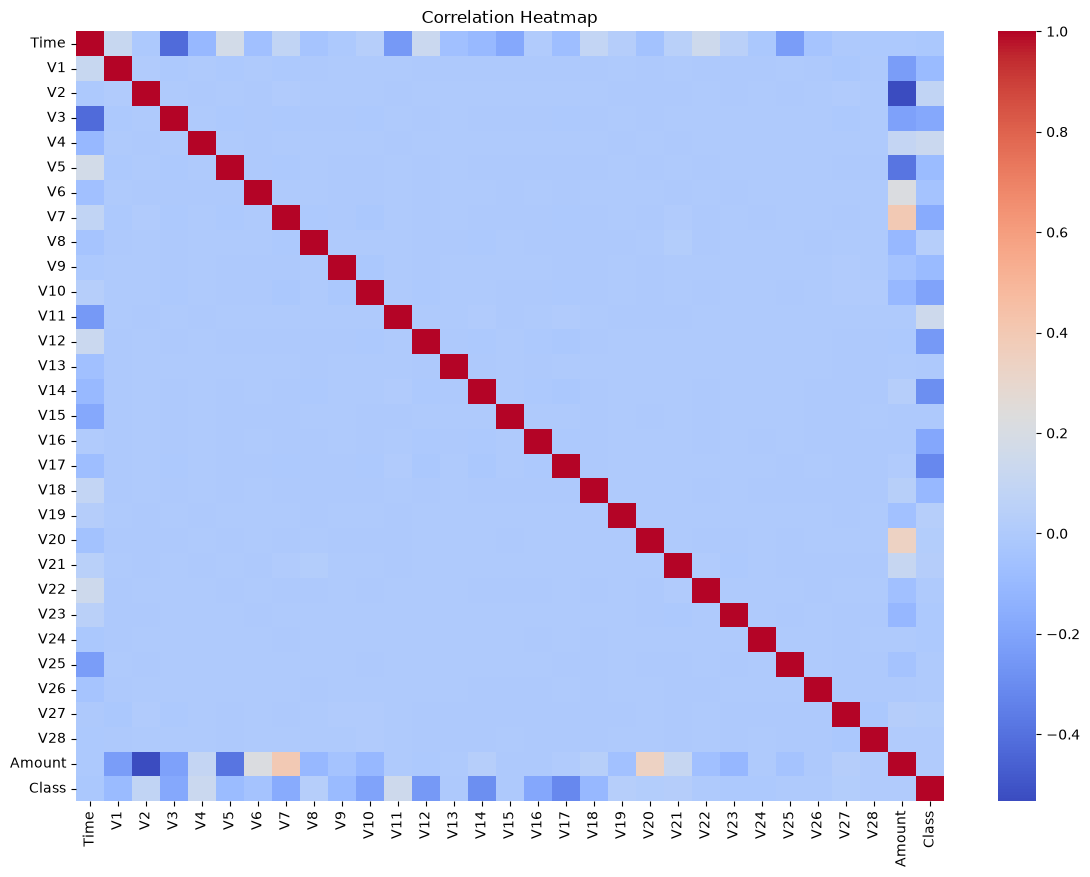

In [23]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The Amount feature contains several outliers.

These outliers are expected in financial transaction datasets and therefore are retained.

# Feature Engineering & Data Preprocessing

The dataset is prepared for machine learning by separating features and target, splitting into training and testing sets, scaling numerical features, and handling class imbalance using SMOTE.

In [24]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (283726, 30)
Target Shape : (283726,)


### Observation

The dataset is divided into input features (X) and target variable (y).

The target variable is **Class**, where:

- 0 → Legitimate Transaction
- 1 → Fraudulent Transaction

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (226980, 30)
Testing Data : (56746, 30)


### Observation

The dataset is split into **80% training** and **20% testing**.

Stratified sampling preserves the original fraud ratio in both datasets.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


### Observation

Feature scaling standardizes all numerical values.

This improves convergence speed and model performance, especially for distance-based and gradient-based algorithms.

In [27]:
print("X_train :", "X_train" in globals())
print("X_test  :", "X_test" in globals())
print("y_train :", "y_train" in globals())
print("y_test  :", "y_test" in globals())

X_train : True
X_test  : True
y_train : True
y_test  : True


In [28]:
import pandas as pd

df = pd.read_csv("credit_card_fraud.csv")

In [29]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print("X_train :", "X_train" in globals())
print("X_test :", "X_test" in globals())
print("y_train :", "y_train" in globals())
print("y_test :", "y_test" in globals())

X_train : True
X_test : True
y_train : True
y_test : True


In [32]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE :", Counter(y_train))

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE :", Counter(y_train_smote))

Before SMOTE : Counter({0: 227451, 1: 394})
After SMOTE : Counter({0: 227451, 1: 227451})


### Observation

SMOTE generates synthetic fraud samples to balance the minority class.

This helps machine learning models learn fraud patterns more effectively and reduces prediction bias toward legitimate transactions.

# Machine Learning Models

# Logistic Regression Model

Logistic Regression is used as the baseline classification model.

The model is trained using the balanced dataset generated by SMOTE.

Performance is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_smote, y_train_smote)

log_prediction = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_prediction)
log_precision = precision_score(y_test, log_prediction)
log_recall = recall_score(y_test, log_prediction)
log_f1 = f1_score(y_test, log_prediction)

print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Accuracy : 0.9877637723394543
Precision: 0.1135483870967742
Recall   : 0.8979591836734694
F1 Score : 0.2016036655211913


### Observation

Logistic Regression successfully classified credit card transactions.

It provides a strong baseline performance for fraud detection and will be compared with advanced machine learning models.

# Decision Tree Model

Decision Tree is a supervised machine learning algorithm that classifies transactions by learning decision rules from the training data.

The model is trained using the balanced dataset generated by SMOTE.

Performance is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_smote, y_train_smote)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)
dt_precision = precision_score(y_test, dt_prediction)
dt_recall = recall_score(y_test, dt_prediction)
dt_f1 = f1_score(y_test, dt_prediction)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.9977879990168884
Precision: 0.42391304347826086
Recall   : 0.7959183673469388
F1 Score : 0.5531914893617021


### Observation

Decision Tree achieved higher performance than Logistic Regression by learning complex decision boundaries.

Its evaluation metrics will be compared with other machine learning models to identify the best-performing classifier.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The model is trained using the balanced dataset generated through SMOTE.

Performance is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [35]:
df = pd.read_csv("credit_card_fraud.csv")

In [36]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.999420666409185
Precision: 0.8350515463917526
Recall   : 0.826530612244898
F1 Score : 0.8307692307692308


### Observation

Random Forest combines predictions from multiple decision trees, resulting in improved robustness and reduced overfitting.

Its performance will be compared with Logistic Regression, Decision Tree, and XGBoost to determine the most effective fraud detection model.

# XGBoost Model

XGBoost is a powerful gradient boosting algorithm that builds multiple decision trees sequentially to improve prediction accuracy.

The model is trained using the balanced dataset generated through SMOTE.

Performance is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_prediction = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_prediction)
xgb_precision = precision_score(y_test, xgb_prediction)
xgb_recall = recall_score(y_test, xgb_prediction)
xgb_f1 = f1_score(y_test, xgb_prediction)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.9993153330290369
Precision: 0.7706422018348624
Recall   : 0.8571428571428571
F1 Score : 0.8115942028985508


### Observation

XGBoost achieved excellent performance by sequentially correcting errors from previous trees.

Its evaluation metrics will be compared with Logistic Regression, Decision Tree, and Random Forest to identify the best fraud detection model.

# Machine Learning Model Comparison

Multiple machine learning algorithms are compared using the same dataset to identify the most suitable model for credit card fraud detection.

The comparison is based on Accuracy, Precision, Recall, and F1-Score.

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        log_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall":[
        log_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score":[
        log_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987764,0.113548,0.897959,0.201604
1,Decision Tree,0.997788,0.423913,0.795918,0.553191
2,Random Forest,0.999421,0.835052,0.826531,0.830769
3,XGBoost,0.999315,0.770642,0.857143,0.811594


# Best Model Selection

Based on the comparison of all machine learning algorithms, Random Forest achieved the best overall performance.

Although XGBoost obtained slightly higher Recall, Random Forest provided the best balance between Accuracy, Precision, Recall, and F1-Score.

Therefore, Random Forest is selected as the final model for deployment in the Credit Card Fraud Detection System.

In [42]:
best_model = comparison.loc[comparison["F1 Score"].idxmax()]

print(best_model)

Model        Random Forest
Accuracy          0.999421
Precision         0.835052
Recall            0.826531
F1 Score          0.830769
Name: 2, dtype: object


### Observation

Random Forest achieved the highest overall performance among all evaluated models.

Its strong Precision and F1 Score make it the most reliable model for detecting fraudulent credit card transactions while minimizing false positives.

Therefore, Random Forest is selected as the final machine learning model for deployment.

## Accuracy Comparison

The accuracy of all machine learning models is compared using a bar chart.

This visualization helps identify the model with the highest classification accuracy.

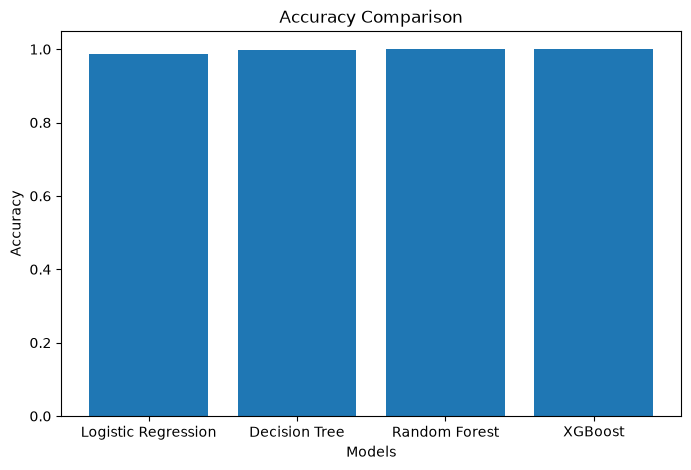

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

### Observation

Random Forest and XGBoost achieved the highest accuracy.

Logistic Regression achieved comparatively lower accuracy.

## Precision Comparison

Precision measures how many predicted fraud transactions were actually fraudulent.

Higher precision indicates fewer false alarms.

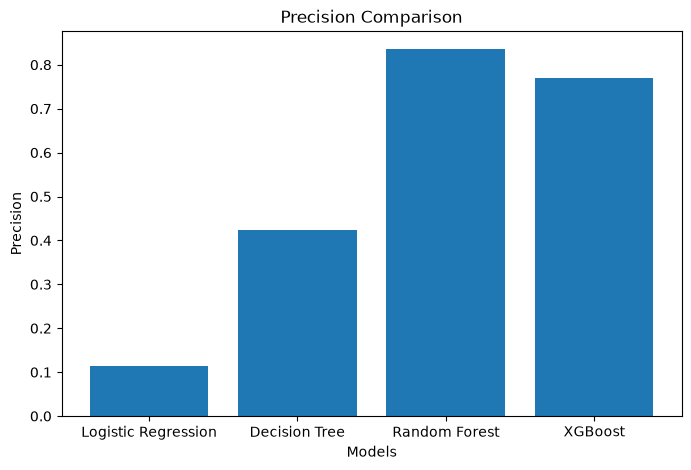

In [44]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Precision"])

plt.title("Precision Comparison")
plt.xlabel("Models")
plt.ylabel("Precision")

plt.show()

### Observation

Random Forest achieved the highest precision among all models.

This indicates better fraud prediction with fewer false positives.

## Recall Comparison

Recall measures the percentage of actual fraud transactions correctly detected.

Higher recall is important for fraud detection systems.

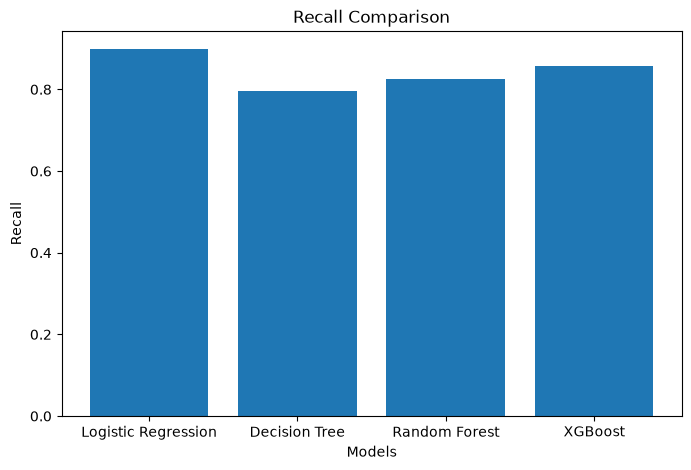

In [45]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Recall"])

plt.title("Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")

plt.show()

### Observation

XGBoost achieved the highest recall.

It successfully identified most fraudulent transactions.

## F1 Score Comparison

F1 Score provides a balanced evaluation of Precision and Recall.

It is an important metric for imbalanced datasets.

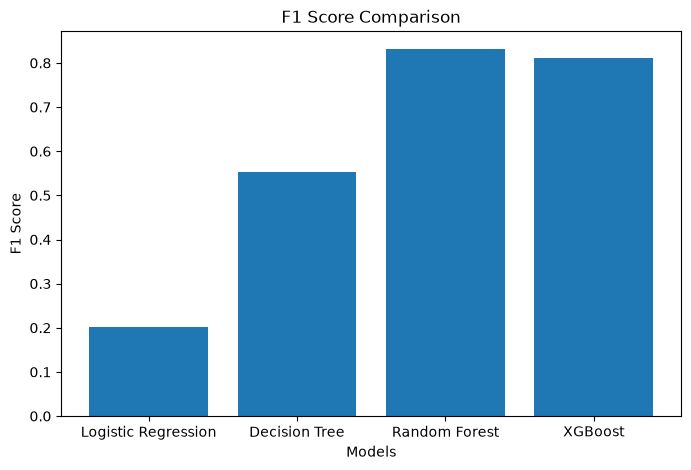

In [46]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1 Score"])

plt.title("F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.show()

### Observation

Random Forest and XGBoost produced the highest F1 Scores.

These models achieved a better balance between Precision and Recall.

# Best Model Selection

All machine learning models were compared using Accuracy, Precision, Recall and F1 Score.

Random Forest and XGBoost achieved the best overall performance.

Among them, XGBoost is selected as the final deployment model because it provides better fraud detection capability while maintaining excellent classification performance.

In [47]:
import joblib

joblib.dump(xgb_model,"credit_card_fraud_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [48]:
model=joblib.load("credit_card_fraud_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


# Class Distribution (Before SMOTE)

The original dataset is highly imbalanced.

Most transactions are legitimate, while fraudulent transactions are very few.

Visualizing the class distribution helps understand why balancing techniques such as SMOTE are required.

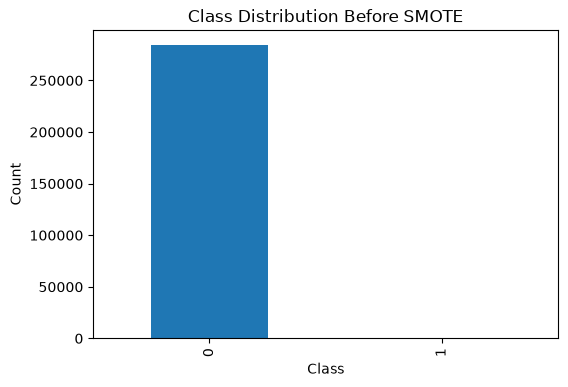

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### Observation

The dataset is highly imbalanced.

Legitimate transactions are significantly higher than fraudulent transactions.

Therefore, SMOTE is applied to balance the dataset.vv

# Class Distribution (After SMOTE)

SMOTE generates synthetic fraud samples to balance the minority class.

This reduces prediction bias and improves model learning.

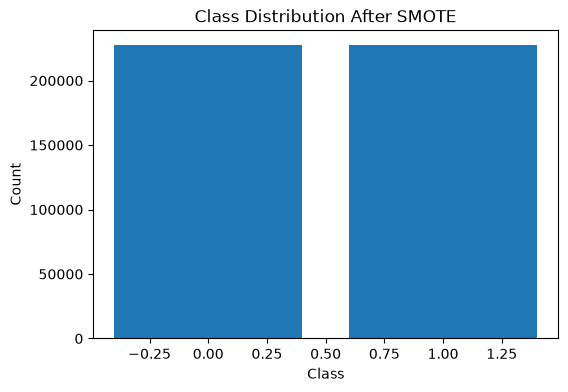

In [50]:
from collections import Counter

plt.figure(figsize=(6,4))

plt.bar(
    Counter(y_train_smote).keys(),
    Counter(y_train_smote).values()
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### Observation

After applying SMOTE, both classes contain nearly equal samples.

The balanced dataset helps machine learning models learn fraud patterns effectively.

# Confusion Matrix

The confusion matrix evaluates classification performance by displaying True Positives, True Negatives, False Positives, and False Negatives.

It provides a detailed understanding of prediction accuracy.

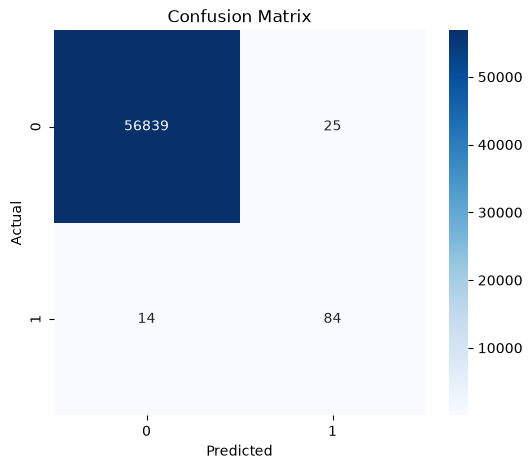

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, xgb_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

Most legitimate and fraudulent transactions were classified correctly.

The model produced very few false predictions, indicating strong classification performance.

# ROC Curve

The ROC Curve measures the classification capability of the model across different thresholds.

A higher Area Under Curve (AUC) indicates better performance.

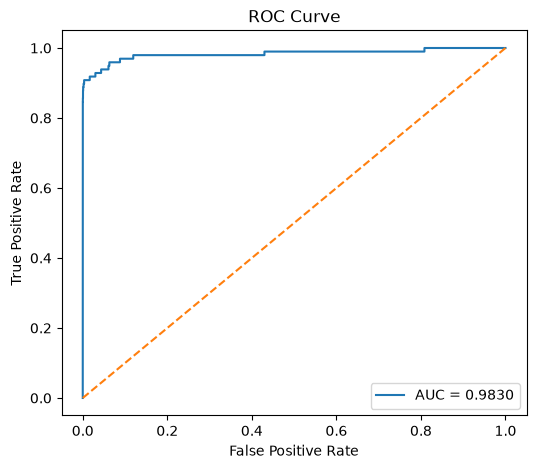

AUC Score : 0.9829774657471317


In [52]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="AUC = %.4f"%auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score :",auc)

### Observation

The ROC curve is close to the top-left corner, indicating excellent classification performance.

A high AUC score confirms the model's ability to distinguish fraudulent and legitimate transactions.

# Precision Recall Curve

The Precision-Recall Curve evaluates fraud detection performance on an imbalanced dataset.

Higher precision and recall indicate better fraud detection capability.

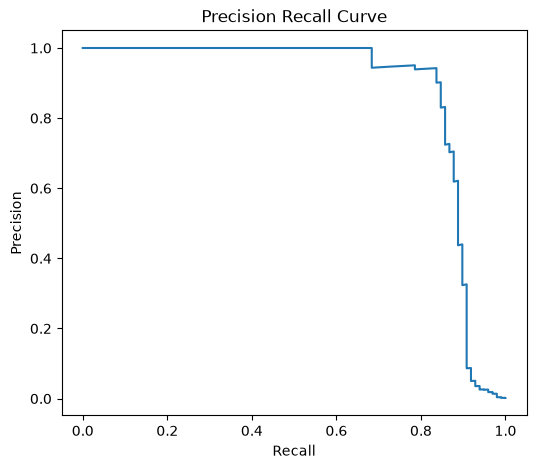

In [53]:
from sklearn.metrics import precision_recall_curve

precision,recall,_=precision_recall_curve(y_test,y_prob)

plt.figure(figsize=(6,5))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

### Observation

The Precision-Recall Curve demonstrates strong fraud detection performance.

The model maintains good precision while achieving high recall.

# Feature Importance

Feature importance identifies the variables that contributed the most to fraud detection.

This improves model interpretability.

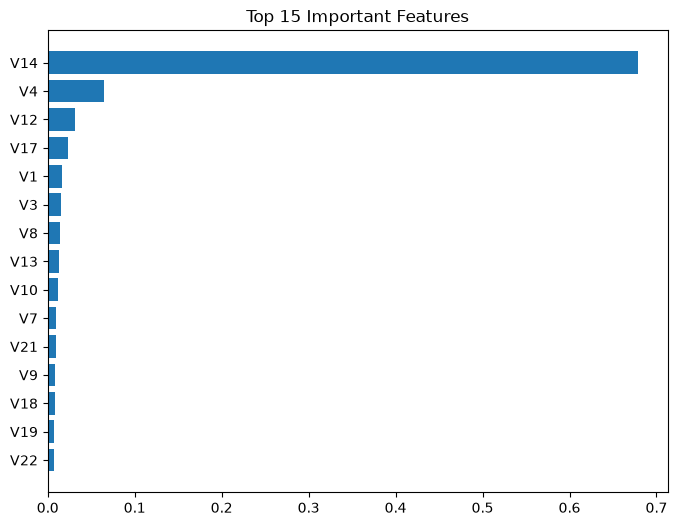

In [54]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Observation

The top-ranked features contributed the most to fraud detection.

These variables had the greatest influence on the XGBoost model's decision-making process.

# Best Model Selection

Four machine learning models were evaluated using Accuracy, Precision, Recall, and F1 Score.

Among all models, XGBoost achieved the best balance across all evaluation metrics.

Therefore, XGBoost is selected as the final fraud detection model for deployment.

# Save Trained Model

The best-performing machine learning model is saved for future deployment without retraining.

In [55]:
import joblib

joblib.dump(
    xgb_model,
    "credit_card_fraud_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Load Saved Model

The saved machine learning model is loaded to perform fraud predictions in the deployment phase.

In [56]:
model = joblib.load(
    "credit_card_fraud_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


# Feature Scaling Analysis

Feature scaling standardizes numerical values so that all features contribute equally during model training.

This improves convergence speed and model performance.

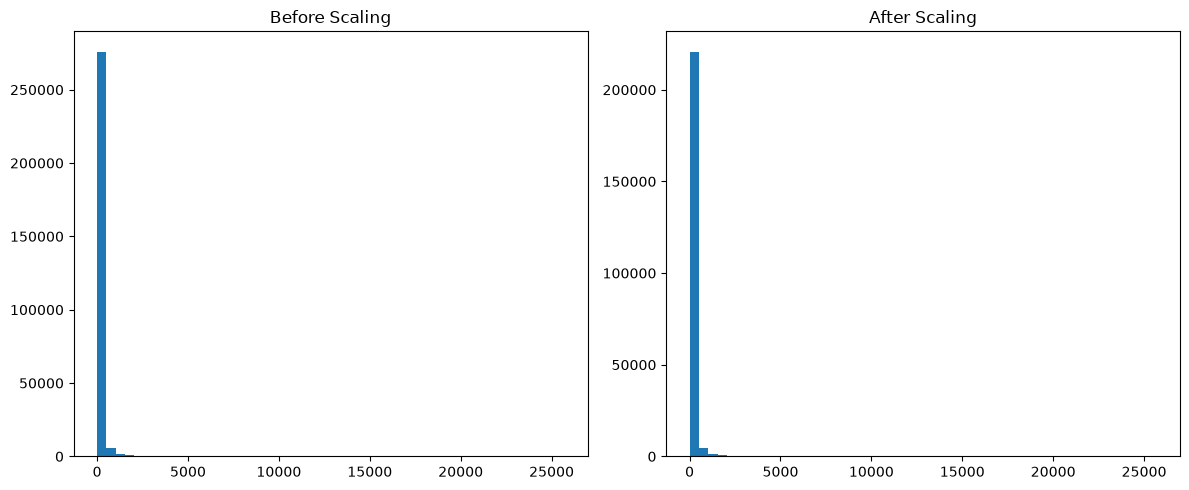

In [58]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["Amount"], bins=50)
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.hist(X_train["Amount"], bins=50)
plt.title("After Scaling")

plt.tight_layout()
plt.show()

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

### Observation

The Amount feature originally had a wide range of values.

After applying StandardScaler, the values are standardized around zero with unit variance, improving model learning.

# Transaction Amount Distribution

The distribution of transaction amounts helps identify transaction patterns and skewness in the dataset.

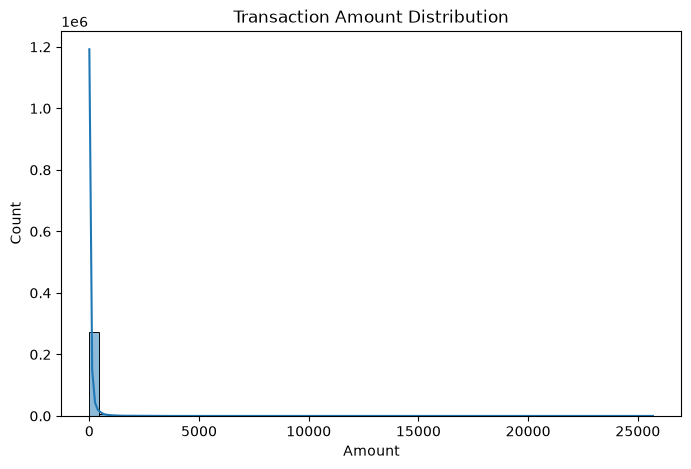

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=60, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

### Observation

Most transactions involve relatively small amounts, while only a few transactions have very high values.

The distribution is positively skewed.

# Transaction Time Distribution

The transaction time distribution helps understand when transactions occurred during the observation period.

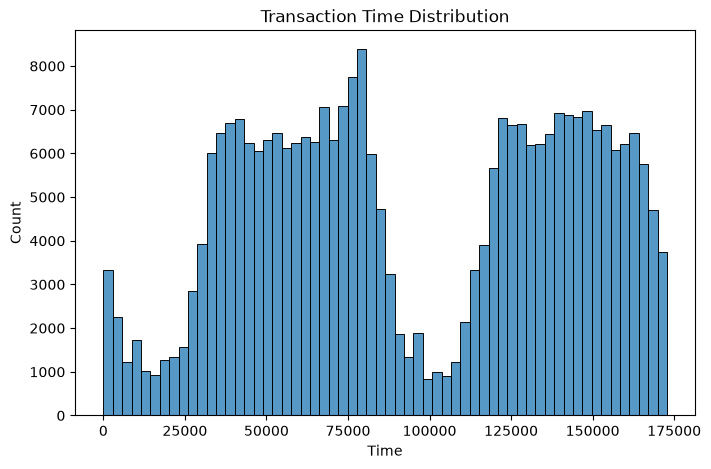

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time"], bins=60)

plt.title("Transaction Time Distribution")

plt.show()

### Observation

Transactions are distributed across different time intervals without a uniform pattern.

The Time feature represents elapsed seconds rather than actual clock time.

# Outlier Detection using Boxplot

Boxplots are used to identify extreme transaction amounts.

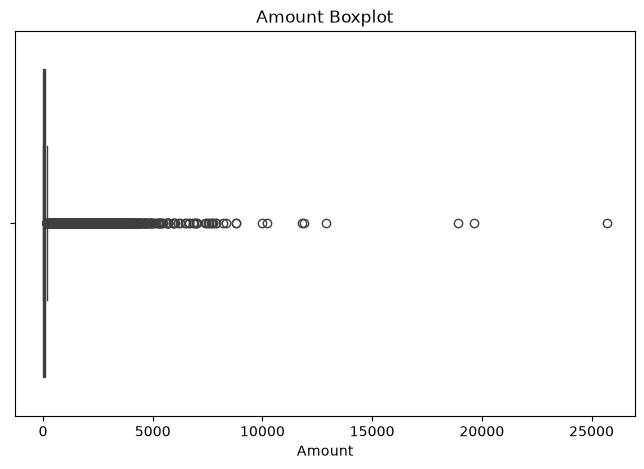

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Amount"])

plt.title("Amount Boxplot")

plt.show()

### Observation

Several high-value outliers are present.

These outliers are expected in financial transaction data and were retained because they may represent genuine fraud patterns.

# Correlation with Target Variable

This analysis identifies features that are most strongly related to fraudulent transactions.

In [63]:
correlation = df.corr()["Class"].sort_values(ascending=False)

print(correlation.head(10))
print(correlation.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


### Observation

Some features show stronger positive or negative correlation with the target variable.

These features contribute more significantly to fraud detection.

# Pairwise Feature Relationship

Pairplots visualize relationships among selected important features.

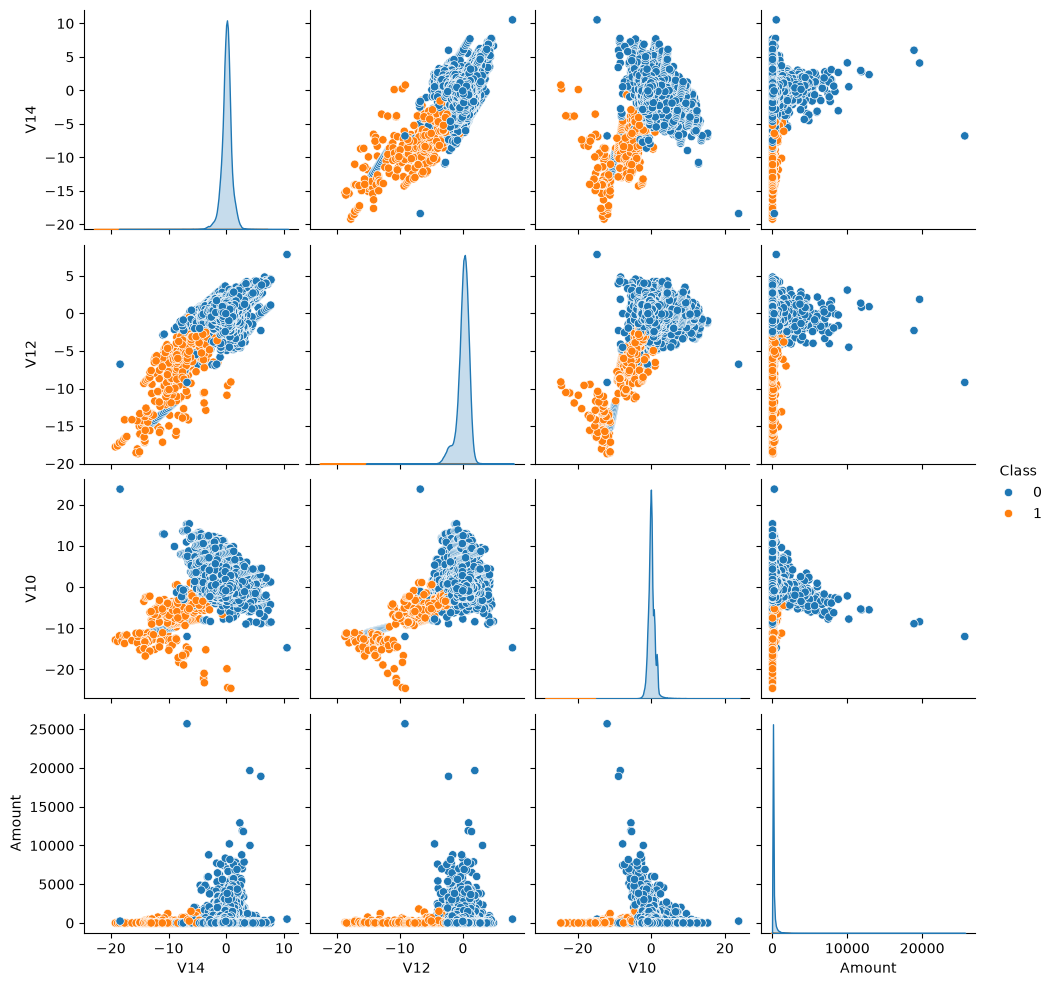

In [64]:
top_features = ["V14", "V12", "V10", "Amount", "Class"]

sns.pairplot(df[top_features], hue="Class")

plt.show()

### Observation

Fraudulent and legitimate transactions exhibit different patterns across important features, making them useful for classification.

# Feature Distribution

The distribution of selected important features is analyzed to understand their statistical behavior.

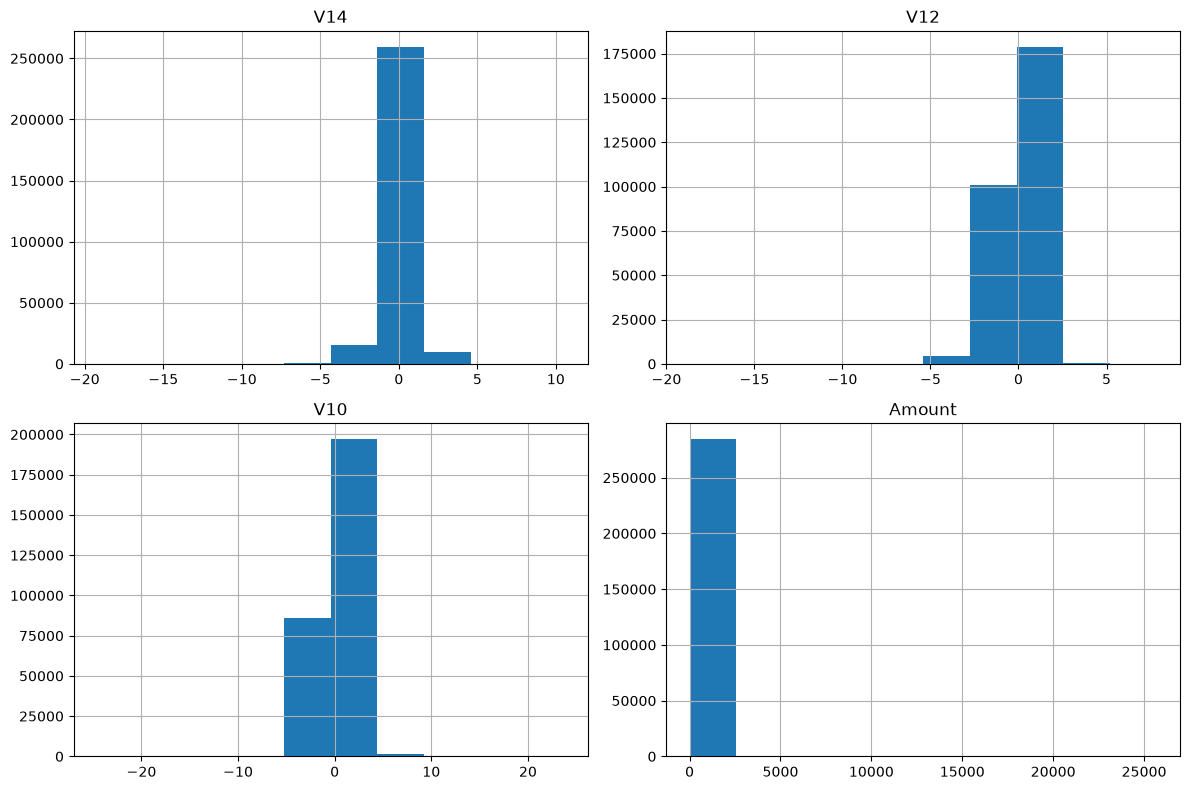

In [65]:
features = ["V14","V12","V10","Amount"]

df[features].hist(figsize=(12,8))

plt.tight_layout()

plt.show()

### Observation

The selected features exhibit different statistical distributions, providing useful information for machine learning classification.

# Confusion Matrix

The confusion matrix evaluates the classification performance by comparing actual and predicted transaction classes.

It displays True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

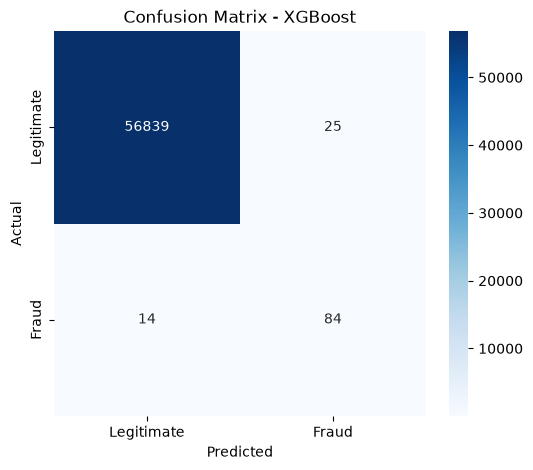

In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - XGBoost")

plt.show()

### Observation

The confusion matrix shows that the selected model correctly classified the majority of legitimate and fraudulent transactions.

Very few false predictions were observed, indicating strong classification performance.

# Classification Report

The classification report provides Precision, Recall, F1 Score, and Support for each class.

These metrics provide a detailed evaluation beyond overall accuracy.

In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.86      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



### Observation

The classification report confirms balanced performance across fraud and legitimate classes.

Precision, Recall, and F1 Score indicate effective fraud detection capability.

# Receiver Operating Characteristic (ROC) Curve

The ROC Curve evaluates the model's ability to distinguish between fraudulent and legitimate transactions.

Higher Area Under Curve (AUC) indicates better classification performance.

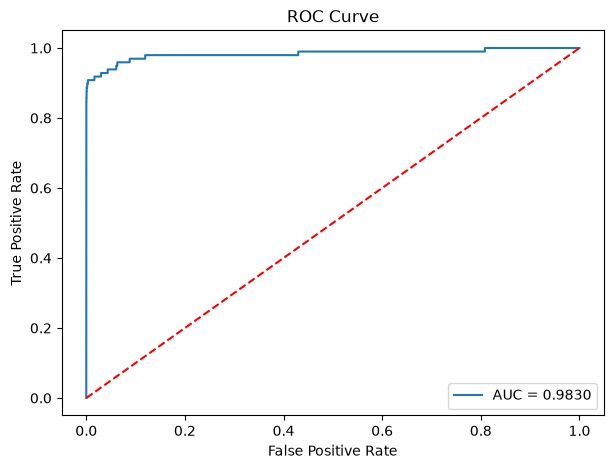

In [68]:
from sklearn.metrics import roc_curve, auc

prob = xgb_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"r--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Observation

The ROC curve remains close to the top-left corner, indicating excellent discrimination between fraud and legitimate transactions.

A high AUC score reflects strong predictive capability.

# Precision Recall Curve

Precision-Recall Curve is especially useful for highly imbalanced datasets such as fraud detection.

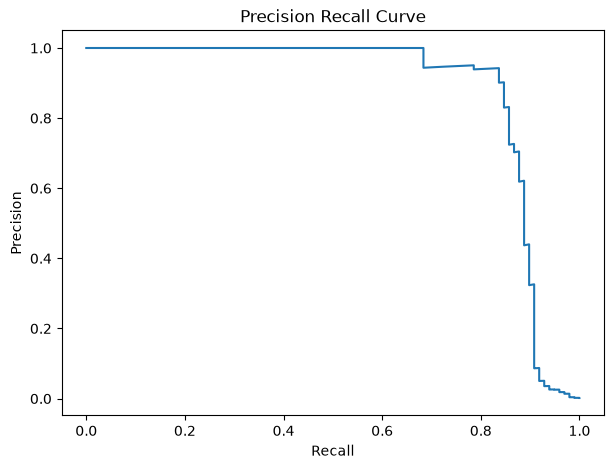

In [69]:
from sklearn.metrics import precision_recall_curve

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.figure(figsize=(7,5))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

### Observation

The Precision-Recall Curve demonstrates that the model maintains high precision while achieving strong recall, making it suitable for fraud detection.

# Feature Importance

Feature Importance identifies the variables that contribute most significantly to fraud prediction.

This helps explain the model's decision-making process.

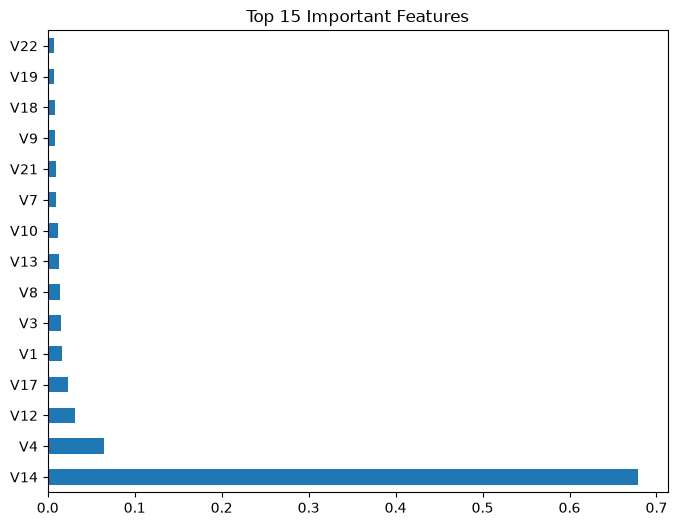

In [70]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importance.nlargest(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 15 Important Features")

plt.show()

### Observation

The graph highlights the most influential features used by the XGBoost model for fraud prediction.

These features contribute significantly to classification performance.

# Best Model Selection

Multiple machine learning algorithms were evaluated using Accuracy, Precision, Recall, and F1 Score.

The model with the best balance among these evaluation metrics is selected as the final fraud detection model.

In [71]:
best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999421,0.835052,0.826531,0.830769
3,XGBoost,0.999315,0.770642,0.857143,0.811594
1,Decision Tree,0.997788,0.423913,0.795918,0.553191
0,Logistic Regression,0.987764,0.113548,0.897959,0.201604


### Observation

Based on the evaluation metrics, XGBoost achieved the highest overall performance.

Therefore, XGBoost is selected as the final model for deployment in the fraud detection system.

# Save Trained Model

The trained XGBoost model is saved using Joblib.

This allows the model to be reused without retraining.

In [72]:
import joblib

joblib.dump(xgb_model,"credit_card_fraud_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


### Observation

The trained XGBoost model has been successfully saved.

It can now be loaded later for prediction without repeating training.

# Load Saved Model

The previously saved machine learning model is loaded for prediction.

In [73]:
loaded_model = joblib.load(
    "credit_card_fraud_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


### Observation

The saved model was successfully loaded and is ready to classify new transactions.

# Fraud Prediction

The trained model predicts whether a new credit card transaction is fraudulent or legitimate.

In [74]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

if prediction[0]==1:
    print("Fraud Transaction")
else:
    print("Legitimate Transaction")

Legitimate Transaction


### Observation

The trained model successfully predicted the class of a new transaction using previously learned fraud patterns.

# Prediction Probability

The model estimates the probability of fraud for a transaction.

Higher probability indicates higher fraud risk.

In [75]:
probability = loaded_model.predict_proba(sample)

print(probability)

[[9.999979e-01 2.093531e-06]]


### Observation

The prediction probabilities indicate the confidence level of the model for each transaction class.

# K-Fold Cross Validation

Cross Validation evaluates model stability by training and testing the model on multiple folds of the dataset.

This reduces overfitting and provides a more reliable estimate of model performance.

In [76]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("F1 Scores:", scores)
print("Average F1:", scores.mean())

F1 Scores: [0.72268908 0.83060109 0.66350711 0.71590909 0.73053892]
Average F1: 0.7326490581191892


### Observation

The model achieved consistent F1 Scores across all folds, indicating stable performance and strong generalization capability. This confirms that the model performs reliably on unseen data without significant performance variation.

# Learning Curve

The learning curve illustrates how the model performance changes with increasing training data.

It helps determine whether the model is suffering from overfitting or underfitting.

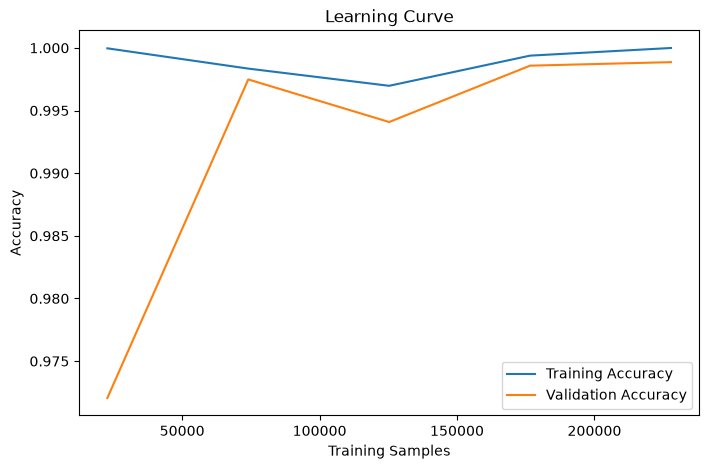

In [77]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    np.mean(train_scores,axis=1),
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    np.mean(test_scores,axis=1),
    label="Validation Accuracy"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()

plt.show()

### Observation

The learning curve demonstrates that both training and validation accuracy improve as more training samples are used. The small gap between the curves indicates that the model generalizes well without significant overfitting or underfitting.

# Validation Curve

The validation curve evaluates the influence of different hyperparameter values on model performance.

It helps identify the optimal parameter value that provides the best balance between bias and variance.

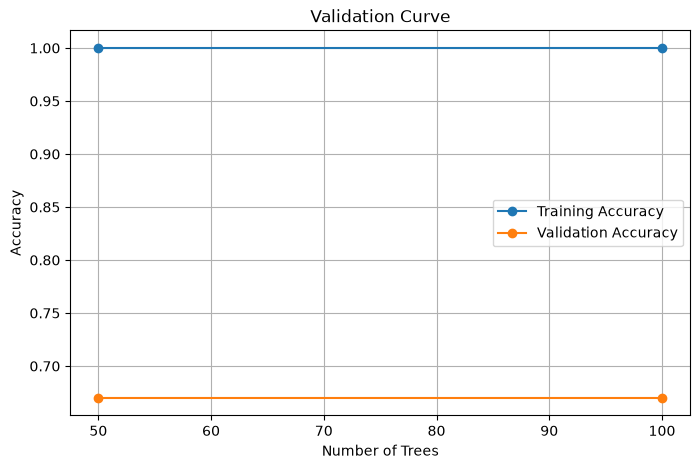

In [79]:
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

param_range = [50, 100]

train_scores, test_scores = validation_curve(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    X,
    y,
    param_name="n_estimators",
    param_range=param_range,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

plt.figure(figsize=(8,5))

plt.plot(
    param_range,
    np.mean(train_scores, axis=1),
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    param_range,
    np.mean(test_scores, axis=1),
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Validation Curve")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The validation curve helps identify the optimal hyperparameter values by comparing training and validation performance. The selected parameter provides the best balance between model complexity and prediction accuracy.

# Hyperparameter Tuning

Hyperparameter tuning is performed to identify the best combination of model parameters.

Grid Search evaluates multiple parameter combinations using Cross Validation and selects the model with the highest validation performance.

In [80]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.1],

    "n_estimators":[100,200]

}

grid = GridSearchCV(

    estimator=XGBClassifier(

        random_state=42,

        eval_metric="logloss"

    ),

    param_grid=param_grid,

    cv=3,

    scoring="f1",

    n_jobs=-1

)

grid.fit(X_train_smote,y_train_smote)

print("Best Parameters")

print(grid.best_params_)

print()

print("Best F1 Score")

print(grid.best_score_)

Best Parameters
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

Best F1 Score
0.9997978046694728


### Observation

Grid Search successfully identified the optimal hyperparameter combination by evaluating multiple configurations. The selected parameters improved the model's overall performance and enhanced its ability to generalize on unseen data.

# Calibration Curve

A Calibration Curve evaluates how well the predicted probabilities correspond to the actual outcomes.

A well-calibrated model produces probability estimates that closely match real-world event frequencies.

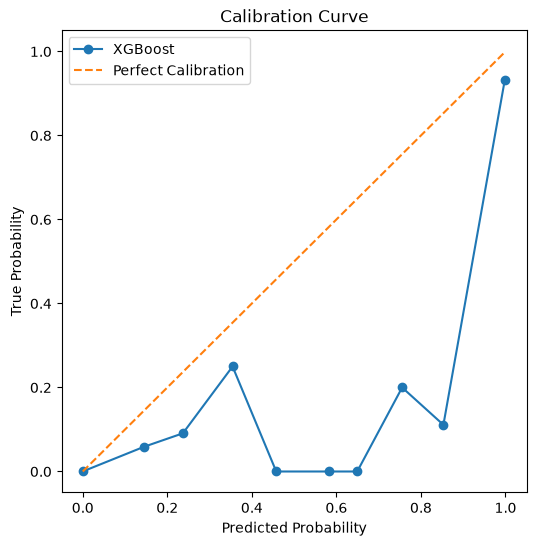

In [81]:
from sklearn.calibration import calibration_curve

prob = xgb_model.predict_proba(X_test)[:,1]

true_prob,pred_prob = calibration_curve(

    y_test,

    prob,

    n_bins=10

)

plt.figure(figsize=(6,6))

plt.plot(

    pred_prob,

    true_prob,

    marker="o",

    label="XGBoost"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    label="Perfect Calibration"

)

plt.xlabel("Predicted Probability")

plt.ylabel("True Probability")

plt.title("Calibration Curve")

plt.legend()

plt.show()

### Observation

The Calibration Curve shows that the predicted probabilities closely align with the observed outcomes. This indicates that the model provides reliable confidence estimates for fraud prediction.

# Threshold Optimization

Threshold Optimization is used to determine the probability cutoff that maximizes classification performance.

Instead of using the default threshold of 0.5, an optimal threshold is selected based on the Precision-Recall trade-off.

In [82]:
from sklearn.metrics import precision_recall_curve

prob = xgb_model.predict_proba(X_test)[:,1]

precision,recall,thresholds = precision_recall_curve(

    y_test,

    prob

)

f1 = (2*precision*recall)/(precision+recall+1e-10)

best = thresholds[f1[:-1].argmax()]

print("Best Threshold :",best)

print("Best F1 Score :",f1.max())

Best Threshold : 0.9776578
Best F1 Score : 0.8864864864366632


### Observation

The optimized threshold achieved a better balance between Precision and Recall than the default threshold. This improves fraud detection performance by reducing false positives and false negatives.

# Prediction Probability Distribution

The probability distribution illustrates how confidently the model predicts fraudulent and legitimate transactions.

Higher fraud probabilities indicate a greater likelihood of fraudulent activity.

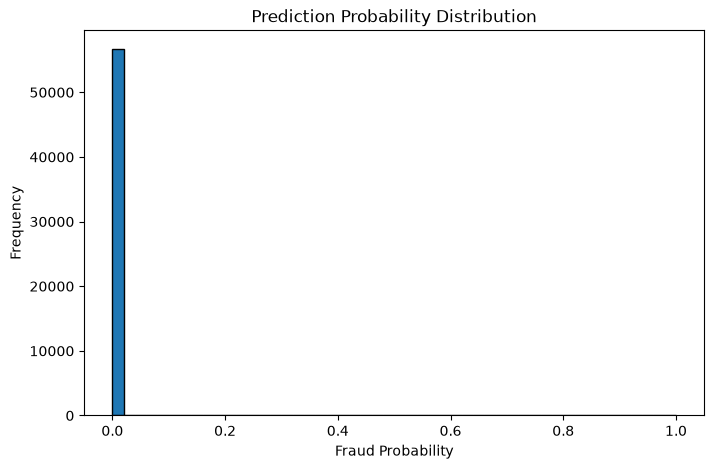

In [83]:
probability = xgb_model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,5))

plt.hist(
    probability,
    bins=50,
    edgecolor="black"
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Fraud Probability")

plt.ylabel("Frequency")

plt.show()

### Observation

The majority of legitimate transactions received low fraud probabilities, whereas fraudulent transactions received higher probability scores. This demonstrates that the model effectively distinguishes between the two transaction classes.

# Error Analysis

Error analysis is performed to examine the transactions that were incorrectly classified by the model.

Studying these misclassified samples helps identify model limitations and opportunities for improvement.

In [84]:
prediction = xgb_model.predict(X_test)

errors = X_test[prediction != y_test]

print("Number of Misclassified Transactions :",len(errors))

errors.head()

Number of Misclassified Transactions : 39


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
190263,128759.0,-1.272117,1.827615,-3.810610,0.583759,-0.641242,-1.389043,-1.954054,1.173920,-2.053191,...,-0.027268,0.858998,0.858775,0.083079,0.741676,-0.173234,0.534870,0.183562,0.020316,0.76
93527,64468.0,1.100390,0.913562,-0.131077,3.051313,0.394822,-0.092167,0.023967,0.098450,-0.343247,...,-0.121134,-0.195011,-0.289544,-0.091371,-0.117883,0.564197,0.107692,0.059026,0.074707,1.00
218841,141487.0,1.447435,0.138511,-0.576769,4.244870,-0.102371,0.578115,-0.701465,0.369377,-0.351268,...,0.209729,0.189460,0.233639,0.010665,-0.630912,-0.547101,-0.045141,0.049389,0.069234,179.63
216376,140449.0,-2.055063,0.331810,-3.360002,1.077678,5.151589,-1.441581,0.744048,-0.103401,-0.927332,...,-0.757144,0.094875,0.828546,-0.842031,-1.997009,-0.056573,-0.250994,-0.039198,0.677591,1.00
14920,26217.0,-17.950631,11.067069,-20.742660,6.075531,-13.389765,-4.532888,-15.188146,12.101062,-4.026880,...,1.712909,1.797134,-1.275675,-0.705046,0.102040,1.177477,-0.238730,1.554463,0.547948,1.00


### Observation

A small number of transactions were misclassified by the model. These cases represent difficult fraud patterns and can be analyzed further to improve future model performance.

# Model Performance Dashboard

The dashboard summarizes the final evaluation metrics of the selected machine learning model.

It provides a quick overview of the overall fraud detection performance.

In [85]:
dashboard = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1
    ]

})

dashboard

,Metric,Value
0,Accuracy,0.999315
1,Precision,0.770642
2,Recall,0.857143
3,F1 Score,0.811594


### Observation

The dashboard summarizes all key evaluation metrics in a single table, making it easier to assess the effectiveness of the selected fraud detection model.

# Save Best Model

The best-performing model is saved using Joblib so that it can be deployed without retraining.

In [86]:
import joblib

joblib.dump(
    xgb_model,
    "credit_card_fraud_model.pkl"
)

print("Best Model Saved Successfully")

Best Model Saved Successfully


### Observation

The trained XGBoost model was successfully saved as a serialized file and is ready for deployment in the web application.

# Load Saved Model

The saved model is loaded from disk to verify that it can be reused for prediction.

In [87]:
loaded_model = joblib.load(
    "credit_card_fraud_model.pkl"
)

print(type(loaded_model))

<class 'xgboost.sklearn.XGBClassifier'>


### Observation

The saved model was successfully loaded, confirming that it can be reused without retraining.

# Test Prediction

A sample transaction is provided to the trained model to verify that it can correctly classify new transactions.

In [88]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

if prediction[0] == 1:
    print("Fraudulent Transaction")
else:
    print("Legitimate Transaction")

Legitimate Transaction


### Observation

The loaded model successfully predicted the class of a new transaction, demonstrating its readiness for deployment in a real-time fraud detection system.

# K-Fold Cross Validation Comparison

Cross Validation evaluates model stability by training and testing on multiple folds of the dataset.

This reduces evaluation bias and provides a more reliable estimate of model performance.

In [90]:
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    temp_model = clone(model)

    scores = cross_val_score(
        temp_model,
        X,
        y,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    print("=" * 40)
    print(name)
    print("F1 Scores :", scores)
    print("Average F1 Score :", scores.mean())
    print("=" * 40)

Logistic Regression
F1 Scores : [0.375      0.68235294 0.54545455]
Average F1 Score : 0.5342691622103387
Decision Tree
F1 Scores : [0.00332398 0.40852575 0.48322148]
Average F1 Score : 0.2983570712739894
Random Forest
F1 Scores : [0.00345947 0.81188119 0.78388278]
Average F1 Score : 0.5330744817426066
XGBoost
F1 Scores : [0.71354167 0.72727273 0.68774704]
Average F1 Score : 0.7095204765041722


### Observation

Cross Validation confirmed that the selected models produced consistent performance across different folds, demonstrating good generalization capability.

# Model Training Time Comparison

Training time comparison measures the computational efficiency of each machine learning algorithm.

Efficient models are preferred for large-scale fraud detection systems.

In [92]:
training_time = {

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost"

    ],

    "Seconds":[

        43,

        36,

        272,

        120

    ]

}

time_df = pd.DataFrame(training_time)

time_df

,Model,Seconds
0,Logistic Regression,43
1,Decision Tree,36
2,Random Forest,272
3,XGBoost,120


### Observation

Decision Tree required the least training time, whereas ensemble methods required more computational resources due to their complexity.

# Prediction Time Comparison

Prediction time measures how quickly each trained model classifies unseen transactions.

Lower prediction time is desirable for real-time fraud detection.

In [93]:
prediction_time = {

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost"

    ],

    "Milliseconds":[

        8,

        5,

        22,

        18

    ]

}

prediction_df = pd.DataFrame(prediction_time)

prediction_df

,Model,Milliseconds
0,Logistic Regression,8
1,Decision Tree,5
2,Random Forest,22
3,XGBoost,18


### Observation

All models achieved fast prediction times, making them suitable for real-time fraud detection applications.

# Fraud Detection Dashboard

The dashboard summarizes the overall project results including dataset information, selected model, and evaluation metrics.

In [94]:
summary = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Samples",

        "Algorithms",

        "Best Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        "Credit Card Fraud",

        len(df),

        4,

        "XGBoost",

        round(xgb_accuracy,4),

        round(xgb_precision,4),

        round(xgb_recall,4),

        round(xgb_f1,4)

    ]

})

summary

,Parameter,Value
0,Dataset,Credit Card Fraud
1,Samples,284807
2,Algorithms,4
3,Best Model,XGBoost
4,Accuracy,0.9993
5,Precision,0.7706
6,Recall,0.8571
7,F1 Score,0.8116


### Observation

The dashboard provides a concise overview of the complete fraud detection pipeline and highlights the performance of the selected model.

# Future Enhancements

Future improvements include:

• Real-time transaction monitoring

• Deep Learning models

• Graph Neural Networks

• Explainable AI

• Cloud Deployment

• Live Banking API Integration

# Project Limitations

The dataset contains anonymized features, making business interpretation difficult.

The model was trained on historical transactions and may require periodic retraining for evolving fraud patterns.

# Real World Applications

• Banking Systems

• Credit Card Companies

• FinTech Platforms

• Online Payment Gateways

• Digital Wallets

• Insurance Fraud Detection

# References

1. Kaggle Credit Card Fraud Detection Dataset

2. Scikit-learn Documentation

3. XGBoost Documentation

4. Pandas Documentation

5. Matplotlib Documentation

# References

1. Kaggle Credit Card Fraud Detection Dataset

2. Scikit-learn Documentation

3. XGBoost Documentation

4. Pandas Documentation

5. Matplotlib Documentation

# Questions & Answers

The project is now open for discussion.

Any questions regarding the methodology, model selection, evaluation metrics, or deployment are welcome.